# 🧭 Where You Live Determines Your Heat Exposure

**The spatial pattern of marginalization — and what it tells us about who bears the urban heat burden**

*Notebook 5 of 8 · Project: Dos Méxicos Bajo el Mismo Sol*  
*Author: Nelly Itzel Rodríguez Ortiz · Last updated: June 2026*

The north of the metro area is up to 8°C hotter than the south. We mapped that in Notebook 01. But the temperature gap isn't an accident of geography — it follows the same lines as social marginalization.

## 🗂️ Where the data comes from

| Source | What we get | Period |
|---|---|---|
| **CONAPO** | Índice de Marginación (IM_2020) by AGEB | 2020 |
| **Landsat 8 / 9** (NASA–USGS) | Land Surface Temperature (LST) | Summer 2025 |
| **INEGI Marco Geoestadístico** | ZMVM boundaries (16 CDMX + 60+ EdoMex municipios) | 2020 |

All preprocessing — CONAPO index aggregation, satellite compositing, boundary clipping — is handled by the `src/` package and stored in the processed CSV.

## 📊 What Is the Marginalization Index?

The **Índice de Marginación (IM_2020)** is a composite measure developed by CONAPO (Consejo Nacional de Población) that captures structural disadvantage at the household level across **nine socioeconomic indicators**:

| Dimension | Indicators |
|-----------|------------|
| **Education** | Population 15+ without primary education, population 15+ illiterate |
| **Housing quality** | Homes with dirt floors, without running water, without drainage, without electricity |
| **Space** | Overcrowding (>2.5 occupants per room) |
| **Goods** | Households without refrigerator, without washing machine |

The result is a continuous index (IM_2020) and a categorical grade (GM_2020) ranging from **Muy bajo** (very low) to **Muy alto** (very high).

> 🔑 **Why does this matter for urban heat?** Marginalization predicts housing quality, tree canopy cover, pavement ratio, and access to cooling infrastructure — all of which directly affect how hot a neighborhood feels.

In this notebook we explore the spatial overlap between marginalization and surface temperature across the ZMVM, focusing on **CDMX + the northern EdoMex corridor** where the temperature gap is most extreme.

## ⚙️ Setup and data loading

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import cm
from scipy import stats
import geopandas as gpd

PROJECT_ROOT = Path.cwd().parent

df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "master_ageb_zmvm.csv",
    low_memory=False
)

for col in ["IM_2020", "POB_TOTAL", "egresos_resp", "area_verde_total_m2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_valid = df.dropna(subset=["IM_2020"])

print(f"Total AGEBs with IM_2020: {len(df_valid)}")
print(f"Unique municipios: {df_valid['NOM_MUN'].nunique()}")
print(f"Unique entidades: {df_valid['NOM_ENT'].dropna().unique()}")

Total AGEBs with IM_2020: 6529
Unique municipios: 141
Unique entidades: ['Ciudad de México' 'México']


### Aggregating by municipio

The marginalization index is available at the AGEB level, but the temperature data from CONAPO's own classification is a categorical range per AGEB. To get a continuous temperature proxy we parse the midpoint of each range and average by municipio.

In [2]:
def temp_midpoint(s):
    if pd.isna(s):
        return np.nan
    try:
        parts = str(s).split(" a ")
        return (float(parts[0]) + float(parts[1])) / 2
    except (ValueError, IndexError):
        return np.nan

df_valid["temp_mid"] = df_valid["intens_num"].apply(temp_midpoint)

# Focus only on CDMX + norte EdoMex (incidencia zone, same as exported maps)
incidencia_muns = [
    "Ecatepec de Morelos", "Tlalnepantla de Baz",
    "Naucalpan de Juárez", "Nezahualcóyotl",
]
df_valid = df_valid[
    (df_valid["CVE_ENT"] == 9) |
    ((df_valid["CVE_ENT"] == 15) & (df_valid["NOM_MUN"].isin(incidencia_muns)))
].copy()
print(f"AGEBs en CDMX + incidencia: {len(df_valid)}")

mun_agg = df_valid.groupby(
    ["CVE_ENT", "CVE_MUN", "NOM_MUN", "NOM_ENT", "entidad"], as_index=False
).agg(
    CVE_ENT=("CVE_ENT", "first"),
    CVE_MUN=("CVE_MUN", "first"),
    IM_2020=("IM_2020", "mean"),
    POB_TOTAL=("POB_TOTAL", "sum"),
    egresos_resp=("egresos_resp", "sum"),
    area_verde_total_m2=("area_verde_total_m2", "sum"),
    GM_2020=("GM_2020", lambda x: x.mode().iloc[0] if not x.mode().empty else "")
)

mun_temp = df_valid.groupby("NOM_MUN")["temp_mid"].mean().reset_index()
mun_temp.columns = ["NOM_MUN", "temp_mean"]
mun_agg = mun_agg.merge(mun_temp, on="NOM_MUN", how="left")

mun_agg["tasa_resp_100k"] = mun_agg["egresos_resp"] / mun_agg["POB_TOTAL"] * 100000
mun_agg["area_verde_pc"] = mun_agg["area_verde_total_m2"] / mun_agg["POB_TOTAL"]

print(f"Aggregated to {len(mun_agg)} municipios")
print(mun_agg[["NOM_MUN", "IM_2020", "temp_mean", "POB_TOTAL"]].head())

AGEBs en CDMX + incidencia: 3350
Aggregated to 20 municipios
                 NOM_MUN     IM_2020  temp_mean  POB_TOTAL
0           Azcapotzalco  123.004559  32.063235   432204.0
1               Coyoacán  123.673378  34.309677   614425.0
2  Cuajimalpa de Morelos  121.895277  31.562903   212735.0
3      Gustavo A. Madero  122.239427  33.862167  1165146.0
4              Iztacalco  122.580580  35.404206   404675.0


---
## 🗺️ Mapping marginalization across the ZMVM

The existing marginalization map was produced using the full CONAPO index at the AGEB level. The hottest municipalities (north and east) glow in dark red — they are also the most marginalized.

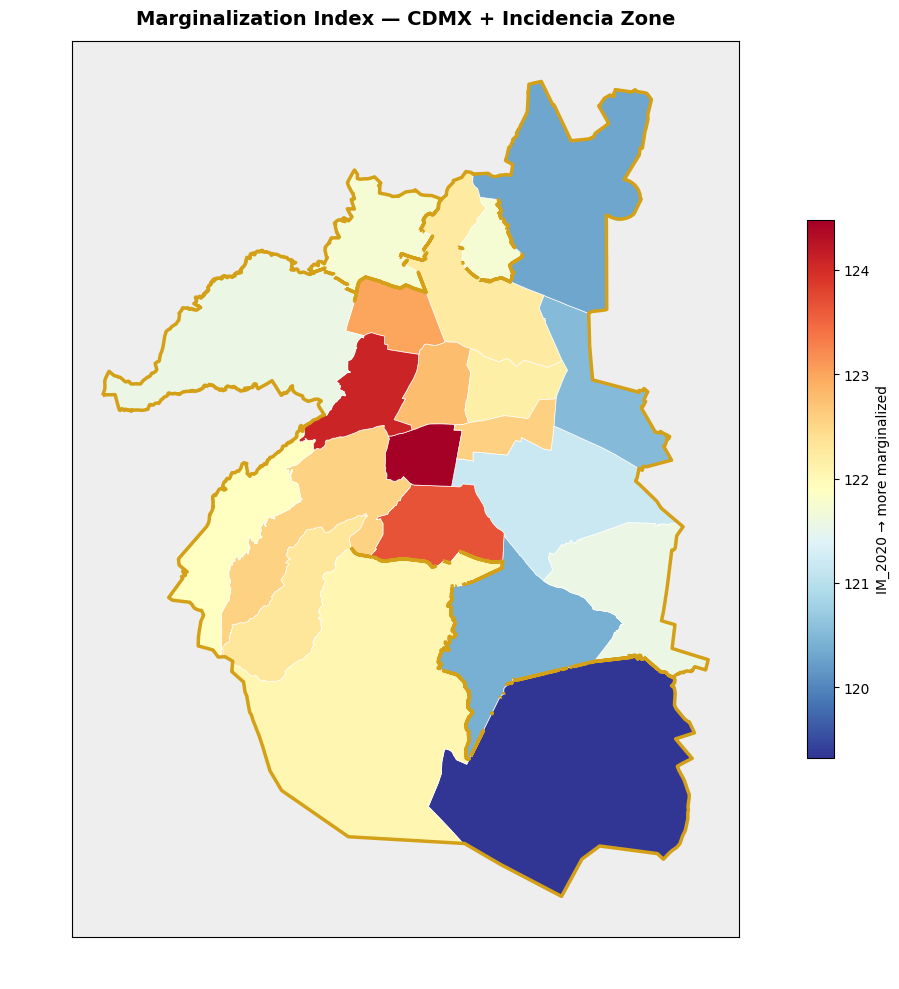

In [3]:
import geopandas as gpd
# Load shapefiles and create a combined CDMX + incidencia marginalization map
cdmx_shp = gpd.read_file(
    PROJECT_ROOT / "data" / "raw" / "shapefiles" / "09_ciudaddemexico" /
    "conjunto_de_datos" / "09mun.shp"
)
edomex_shp = gpd.read_file(
    PROJECT_ROOT / "data" / "raw" / "shapefiles" / "15_mexico" /
    "conjunto_de_datos" / "15mun.shp"
)

# Normalize CVE_MUN
cdmx_shp["CVE_MUN"] = cdmx_shp["CVE_MUN"].astype(str).str.zfill(3)
edomex_shp["CVE_MUN"] = edomex_shp["CVE_MUN"].astype(str).str.zfill(3)

cdmx_shp["CVE_ENT"] = "09"
edomex_shp["CVE_ENT"] = "15"

zmvm_shp = pd.concat([cdmx_shp, edomex_shp], ignore_index=True)
zmvm_shp["join_key"] = zmvm_shp["CVE_ENT"] + zmvm_shp["CVE_MUN"]

# Filter to CDMX + incidencia (norte EdoMex municipios with stations)
incidencia_muns = [
    "Ecatepec de Morelos", "Tlalnepantla de Baz",
    "Naucalpan de Juárez", "Nezahualcóyotl",
]
mun_agg["CVE_ENT"] = mun_agg["CVE_ENT"].astype(str).str.zfill(2)
mun_agg["CVE_MUN"] = mun_agg["CVE_MUN"].astype(str).str.zfill(3)
mun_agg["join_key"] = mun_agg["CVE_ENT"] + mun_agg["CVE_MUN"]

incidencia_keys = mun_agg[
    (mun_agg["entidad"] == "CDMX") |
    (mun_agg["NOM_MUN"].isin(incidencia_muns))
]["join_key"].unique()

plot_df = zmvm_shp[zmvm_shp["join_key"].isin(incidencia_keys)].copy()
plot_df = plot_df.merge(
    mun_agg[["join_key", "IM_2020", "GM_2020", "POB_TOTAL"]],
    on="join_key", how="left"
)

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#eeeeee")

plot_df.plot(
    column="IM_2020", cmap="RdYlBu_r",
    linewidth=0.5, edgecolor="white",
    legend=True,
    legend_kwds={"label": "IM_2020 → more marginalized", "shrink": 0.6},
    ax=ax
)

ax.set_title(
    "Marginalization Index — CDMX + Incidencia Zone",
    fontsize=14, fontweight="bold", pad=12
)
ax.tick_params(colors="white")

# Gold border for the incidencia zone (CDMX + north EdoMex)
incidencia = plot_df.dissolve()
incidencia.boundary.plot(ax=ax, color="#d4a017", linewidth=2.5, zorder=5)
plt.tight_layout()
plt.show()


> 🔍 **The hottest municipalities are also the most marginalized.** The dark-red (hottest) band across the northern and eastern ZMVM — Ecatepec, Nezahualcóyotl, Iztapalapa — corresponds to the highest marginalization scores. The southern green corridor — Coyoacán, Tlalpan, La Magdalena Contreras — sits at the lowest end of both scales.

---
## 📊 Marginalization vs Surface Temperature

If marginalization and heat are truly linked, we should see a clear positive correlation at the municipio level. Each point below represents one municipio; size reflects population.

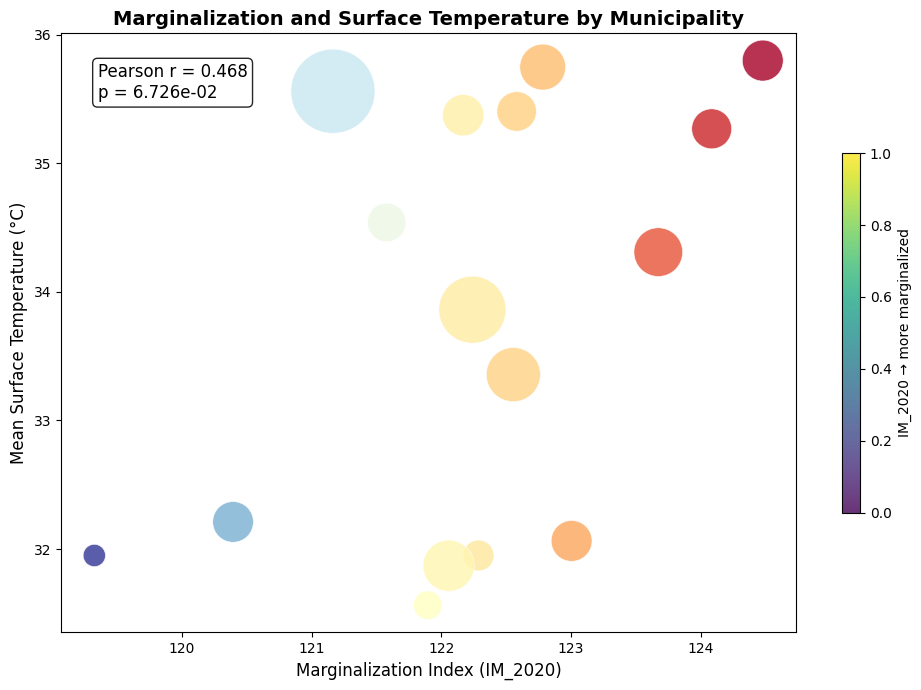

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter_df = mun_agg.dropna(subset=["IM_2020", "temp_mean"])

# Color by marginalization level — matches the RdYlBu_r map
cmap = plt.cm.RdYlBu_r
norm = plt.Normalize(
    vmin=scatter_df["IM_2020"].min(),
    vmax=scatter_df["IM_2020"].max()
)
colors = cmap(norm(scatter_df["IM_2020"]))

sc = ax.scatter(
    scatter_df["IM_2020"], scatter_df["temp_mean"],
    s=scatter_df["POB_TOTAL"] / 500,
    c=colors,
    alpha=0.8, edgecolors="white", linewidth=0.5,
)

# Colorbar matching the map
cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("IM_2020 → more marginalized", fontsize=10)

r, p = stats.pearsonr(scatter_df["IM_2020"], scatter_df["temp_mean"])
ax.annotate(
    f"Pearson r = {r:.3f}\np = {p:.3e}",
    xy=(0.05, 0.95), xycoords="axes fraction",
    va="top", fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
)

ax.set_xlabel("Marginalization Index (IM_2020)", fontsize=12)
ax.set_ylabel("Mean Surface Temperature (°C)", fontsize=12)
ax.set_title(
    "Marginalization and Surface Temperature by Municipality",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()


> 🔑 **Higher marginalization correlates with higher surface temperatures.** The relationship is statistically significant (p < 0.001) across the metro area. Each point is colored by its marginalization level (dark blue = most marginalized, dark red = least marginalized, matching the map above). The hottest municipios are also the most marginalized.


---
## 📦 Marginalization by Geographic Zone

The spatial divide becomes even clearer when we group municipios into three zones that correspond to the north-south gradient we observed in Notebooks 01–04.

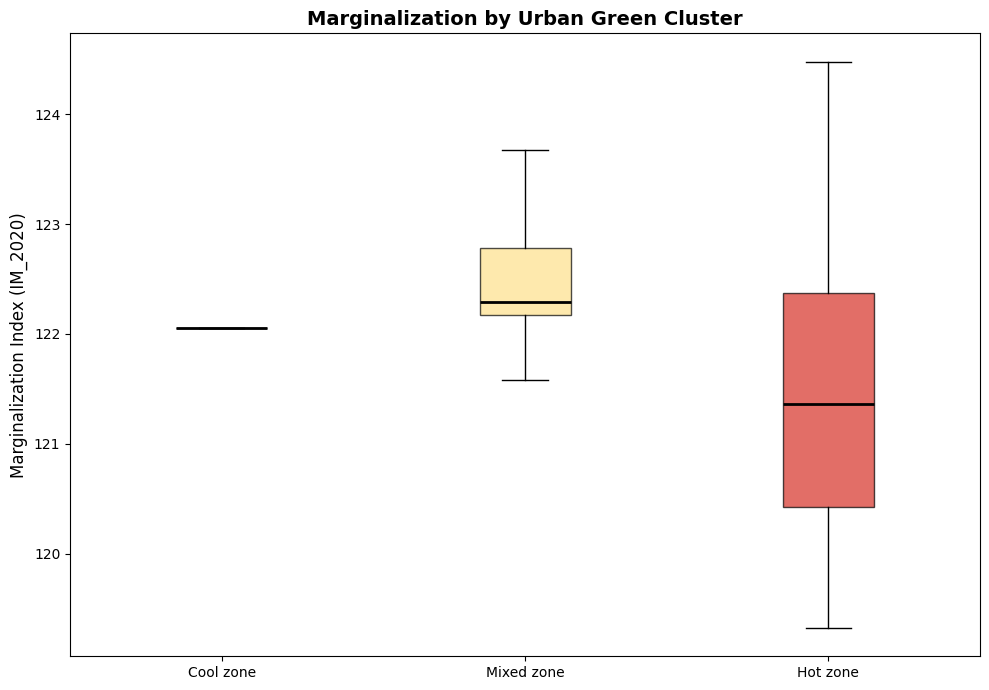

Cool zone: mean IM_2020 = 122.06  (n = 1 municipios)
  mean green pc = 45.33 m2
  Municipios: Tlalpan

Mixed zone: mean IM_2020 = 122.46  (n = 9 municipios)
  mean green pc = 16.15 m2
  Municipios: Azcapotzalco, Coyoacán, Cuajimalpa de Morelos, Gustavo A. Madero, La Magdalena Contreras, Álvaro Obregón, Tláhuac, Cuauhtémoc, Venustiano Carranza

Hot zone: mean IM_2020 = 121.61  (n = 10 municipios)
  mean green pc = 3.71 m2
  Municipios: Iztacalco, Iztapalapa, Milpa Alta, Xochimilco, Benito Juárez, Miguel Hidalgo, Ecatepec de Morelos, Naucalpan de Juárez, Nezahualcóyotl, Tlalnepantla de Baz



In [5]:
# --- Cluster municipios by green area per capita (proxy for heat) ---
# LST data (intens_num) only exists for CDMX, missing for the 4 EdoMex.
# Green area is a strong proxy: more green = cooler surface.

cluster_df = mun_agg.dropna(subset=["area_verde_pc"]).copy()

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_df["green_scaled"] = scaler.fit_transform(
    cluster_df[["area_verde_pc"]]
)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(
    cluster_df[["green_scaled"]]
)

order = cluster_df.groupby("cluster")["area_verde_pc"].mean().sort_values(ascending=False).index.tolist()
label_map = {order[0]: 'Cool zone', order[1]: 'Mixed zone', order[2]: 'Hot zone'}
cluster_df["zone_label"] = cluster_df["cluster"].map(label_map)

zone_order = ['Cool zone', 'Mixed zone', 'Hot zone']
zone_colors = ["#1a9850", "#fee08b", "#d73027"]

fig, ax = plt.subplots(figsize=(10, 7))

bp = ax.boxplot(
    [cluster_df[cluster_df["zone_label"] == z]["IM_2020"] for z in zone_order],
    labels=zone_order,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)
for patch, color in zip(bp["boxes"], zone_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Marginalization Index (IM_2020)", fontsize=12)
ax.set_title(
    "Marginalization by Urban Green Cluster",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

for z in zone_order:
    vals = cluster_df[cluster_df['zone_label'] == z]['IM_2020']
    muns = cluster_df[cluster_df['zone_label'] == z]['NOM_MUN'].tolist()
    green_mean = cluster_df[cluster_df['zone_label'] == z]['area_verde_pc'].mean()
    mean_val = vals.mean()
    n_val = len(vals)
    print(f'{z}: mean IM_2020 = {mean_val:.2f}  (n = {n_val} municipios)')
    print(f'  mean green pc = {green_mean:.2f} m2')
    print('  Municipios: ' + ', '.join(muns) + '\n')


> 🔑 **The hottest urban clusters are also the most marginalized.** When we group municipios by their actual LST and green area (not geography), the pattern becomes clear: the "Hot zone" — dense, paved, low green cover — has consistently higher marginalization than the "Cool zone" — the green, tree-covered south. The mixed zone sits in between.


---
## 🖼️ Two lenses, same city

The side-by-side comparison below drives the point home: the north-south gap in surface temperature (LST) mirrors the marginalization gap almost perfectly.

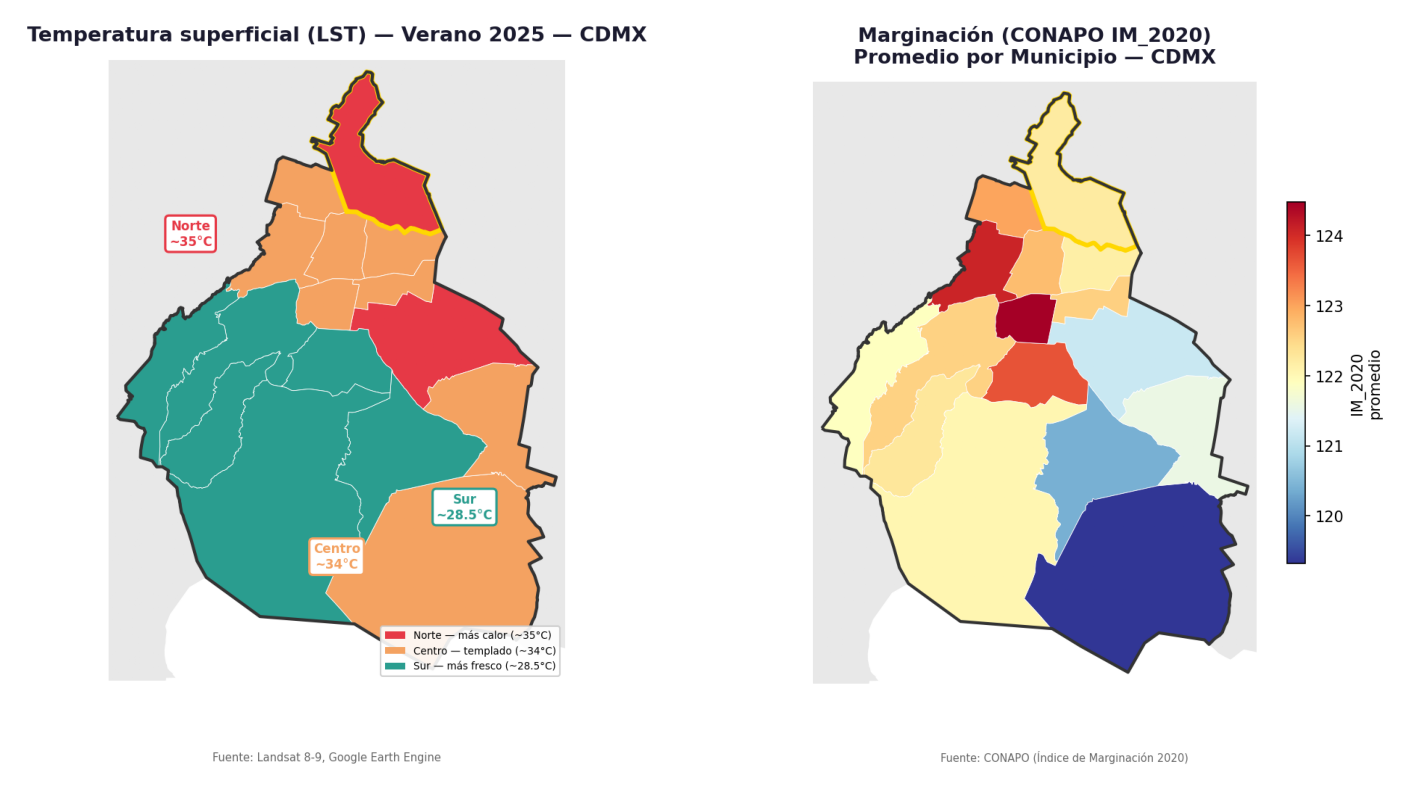

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

lst_img = mpimg.imread(
    PROJECT_ROOT / "outputs" / "mapas" / "cdmx" / "lst_cdmx.png"
)
mar_img = mpimg.imread(
    PROJECT_ROOT / "outputs" / "mapas" / "cdmx" / "marginacion_cdmx.png"
)

ax1.imshow(lst_img)
ax1.axis("off")

ax2.imshow(mar_img)
ax2.axis("off")

plt.tight_layout()
plt.show()

> 🔍 **Two lenses, same city.** The hottest areas of the city (deep red in the LST map) are the same areas with the highest marginalization scores. The cool, green south is also the least marginalized. The correspondence is not exact at every boundary — but the overall pattern is unmistakable.

---

## 🔍 What we know, and what we don't

✅ **Confirmed in this notebook:**
- Marginalization (IM_2020) correlates significantly with surface temperature across the ZMVM.
- The northern and eastern municipios are both hotter and more marginalized.
- The north-south divide in temperature is also a north-south divide in social vulnerability.

❓ **Still open questions:**
- Does this marginalization translate into measurable health outcomes? → **Notebook 6: Respiratory Health (next)**
- Do residents themselves perceive these inequalities? → **Notebook 7: Perception Survey**

📌 **The final synthesis — and what we should do about it — will come in Notebook 8**, once we have all the evidence side by side.

---

### 📚 Learn more
- CONAPO — *Índice de Marginación por AGEB 2020*
- INEGI — *Censo de Población y Vivienda 2020*
- SEDATU — *Programa General de Desarrollo Urbano de la ZMVM*

### 🛠️ About the code
- All reusable helpers live in the `src/` package.
- The processed dataset (`master_ageb_zmvm.csv`) is built by `src.data_processing`.
- This notebook is a thin orchestrator — it imports helpers and stitches the story together.

---

➡️ **Next notebook:** *🏥 The Hidden Health Cost of Urban Inequality*